# Clustering an PCA - recitation

``
In this recitation, you will experience with implementing linear two clustering models: KMeans and DBSCAN. You will also implement a linear decomposition algorithm, PCA.
``

In [1]:
from matplotlib import pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs

from unsupervised_init import LOGGER, RANDOM_SEED

%matplotlib inline

plt.style.use("seaborn-v0_8-whitegrid")

``
Start by generatig data and visualise it. Try to pick an insteresting looking dataset.
``

In [2]:
NUM_SAMPLES = 500
BLOB_CENTERS = np.array(
    object=[[-4.0, -2.0], [0.0, 4.0], [4.0, -1.0]],
    dtype=np.float64,
)
BLOB_STANDARD_DEVIATIONS = [0.55, 0.75, 0.65]

clustering_data, ground_truth_labels = make_blobs(
    n_samples=NUM_SAMPLES,
    centers=BLOB_CENTERS,
    cluster_std=BLOB_STANDARD_DEVIATIONS,
    random_state=RANDOM_SEED,
)
LOGGER.info(
    msg=(
        f"Generated {clustering_data.shape[0]} samples with "
        f"{clustering_data.shape[1]} features."
    )
)

2026-08-31 13:47:54,131 | INFO | clustering_pca_recitation | Generated 500 samples with 2 features.


``
Plot the generated data
``

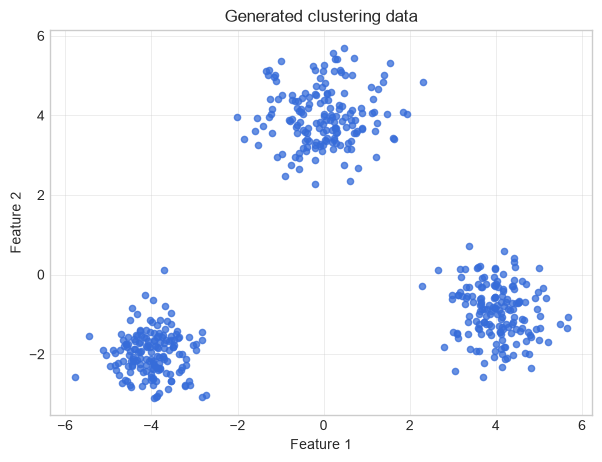

In [3]:
data_figure, data_axes = plt.subplots(figsize=(7, 5))
data_axes.scatter(
    x=clustering_data[:, 0],
    y=clustering_data[:, 1],
    s=20,
    alpha=0.75,
)
data_axes.set(
    title="Generated clustering data",
    xlabel="Feature 1",
    ylabel="Feature 2",
)
plt.show()

In [4]:
# Reusable functions are kept in unsupervised_utils.py and imported after each prompt.

# KMeans


``
Implement the KMeans algorithm. Use wikipedia and google if you aren't sure what to do.
``

In [5]:
from unsupervised_utils import get_closest_center, kmeans

K-Means alternates between assigning every point to its nearest center and replacing each center with its cluster mean. It stops when no center moves by more than `eps`.

``
Plot your results
``

2026-08-31 13:47:54,397 | INFO | clustering_pca_recitation | K-Means converged in 2 iterations.


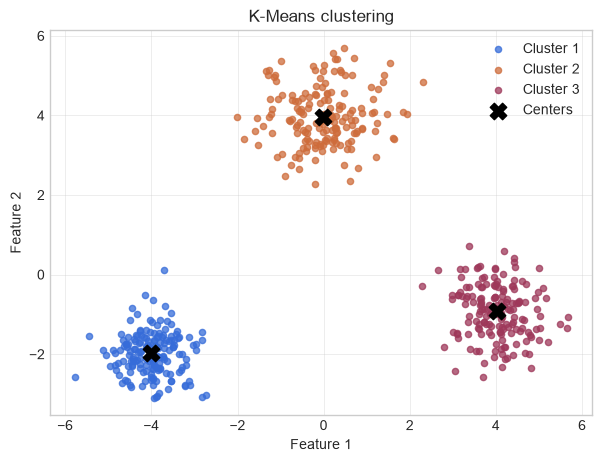

In [6]:
from unsupervised_utils import plot_clusters

kmeans_cluster_points, kmeans_centers = kmeans(
    data=clustering_data,
    clusters_num=3,
    random_seed=RANDOM_SEED,
)
kmeans_figure = plot_clusters(
    clusters_points=kmeans_cluster_points,
    title="K-Means clustering",
)
kmeans_axes = kmeans_figure.axes[0]
kmeans_axes.scatter(
    x=kmeans_centers[:, 0],
    y=kmeans_centers[:, 1],
    c="black",
    marker="X",
    s=140,
    label="Centers",
)
kmeans_axes.legend()
plt.show()

# DBSCAN

``
Implement the DBSCAN algorithm. Again, use wikipedia and google if you aren't sure what to do.
``

In [7]:
from unsupervised_utils import dbscan, get_neighbors

DBSCAN expands a cluster from core points. Here, `min_points` includes the point itself, while samples not density-reachable from a core point receive the noise label `-1`.

``
Plot your results
``

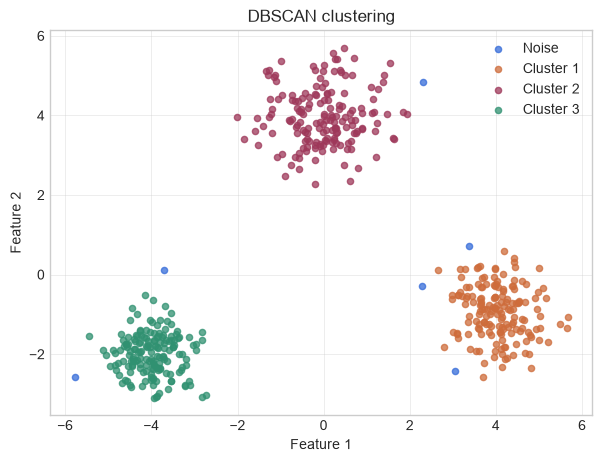

2026-08-31 13:47:54,752 | INFO | clustering_pca_recitation | DBSCAN found 3 clusters and marked 6 samples as noise.


In [8]:
dbscan_labels = dbscan(
    data=clustering_data,
    eps=0.55,
    min_points=5,
)
unique_dbscan_labels = np.unique(ar=dbscan_labels)
dbscan_cluster_points = [
    clustering_data[dbscan_labels == current_label]
    for current_label in unique_dbscan_labels
]
dbscan_cluster_names = [
    "Noise" if current_label == -1 else f"Cluster {int(current_label)}"
    for current_label in unique_dbscan_labels
]
dbscan_figure = plot_clusters(
    clusters_points=dbscan_cluster_points,
    title="DBSCAN clustering",
    cluster_names=dbscan_cluster_names,
)
plt.show()

dbscan_cluster_count = int(
    np.sum(a=unique_dbscan_labels >= 0)
)
dbscan_noise_count = int(np.sum(a=dbscan_labels == -1))
LOGGER.info(
    msg=(
        f"DBSCAN found {dbscan_cluster_count} clusters and marked "
        f"{dbscan_noise_count} samples as noise."
    )
)

# PCA

``
Read about PCA and it's relation to the SVD algorithm. a good source can be found here: https://intoli.com/blog/pca-and-svd/.
In this section we will implement a simple version of PCA wehre you calculate all of the compomemts.

Don't forget to first change the mean of your data to 0.
``

In [9]:
from unsupervised_utils import pca

PCA first centers the features. The right singular vectors form the principal directions, and their signs may be reversed without changing the PCA solution.

``
Plot your results
``

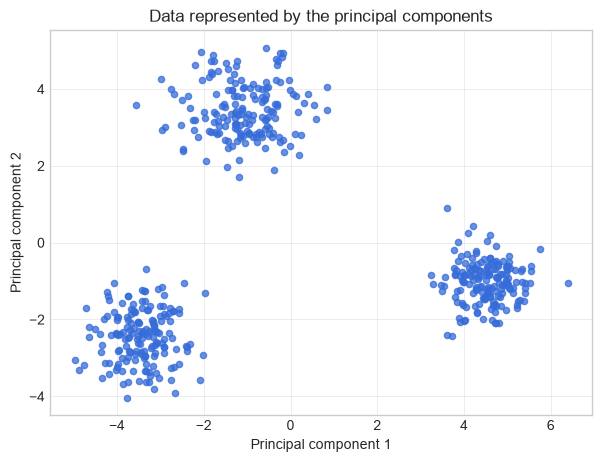

In [10]:
pca_transformed_data, pca_components = pca(data=clustering_data)

pca_figure, pca_axes = plt.subplots(figsize=(7, 5))
pca_axes.scatter(
    x=pca_transformed_data[:, 0],
    y=pca_transformed_data[:, 1],
    s=20,
    alpha=0.75,
)
pca_axes.set(
    title="Data represented by the principal components",
    xlabel="Principal component 1",
    ylabel="Principal component 2",
)
plt.show()

``
Compare with sklearn.decomposition.PCA
``

In [11]:
from sklearn.decomposition import PCA

In [12]:
sklearn_pca = PCA(
    n_components=clustering_data.shape[1],
    svd_solver="full",
)
sklearn_transformed_data = sklearn_pca.fit_transform(X=clustering_data)

component_alignment = np.abs(
    np.diag(v=pca_components @ sklearn_pca.components_.T)
)
LOGGER.info(
    msg=(
        "Absolute alignment with sklearn components: "
        f"{np.round(a=component_alignment, decimals=6).tolist()}"
    )
)
component_alignment

2026-08-31 13:47:55,129 | INFO | clustering_pca_recitation | Absolute alignment with sklearn components: [1.0, 1.0]


array([1., 1.])